In [5]:
import os
import numpy as np 
import pandas as pd
import shutil as sh
from PIL import Image
from tqdm.auto import tqdm

In [6]:
img_h = 12
img_w = 15

In [7]:
os.listdir('spec_images')

['_darknet.labels']

In [8]:
df = pd.read_csv('wf_labelled_data.csv')

In [9]:
df

,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id
0,2022-06-14 10:58:06,RICHFIELDM1_20220413_133400_start_4_40.wav,4.923573,9.344178,0.930820,2.152327,Rook,NaN,1.0,NaN,anthony.gibbons.2022@mumail.ie,1
1,2022-06-14 10:58:22,RICHFIELDM1_20220413_133400_start_4_40.wav,11.691844,13.664883,3.279873,7.320244,Blackbird,NaN,1.0,NaN,anthony.gibbons.2022@mumail.ie,1
2,2022-06-14 14:19:14,RICHFIELDM1_20220413_133400_start_0_42.wav,8.345171,13.290255,1.118744,2.857043,Rook,NaN,1.0,NaN,anthony.gibbons.2022@mumail.ie,1
3,2022-06-16 16:41:55,RICHFIELDM1_20220413_133400_start_0_42.wav,9.169352,11.741794,2.997986,8.353827,Wren,NaN,1.0,NaN,anthony.gibbons.2022@mumail.ie,1
4,2022-06-16 16:43:52,RICHFIELDM1_20220413_133400_start_0_56.wav,0.003464,2.188792,0.742896,2.528176,Rook,NaN,1.0,NaN,anthony.gibbons.2022@mumail.ie,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1410,2022-05-21 21:19:54,1_SMU05115_20211104_064902_start_39_16.wav,4.982504,5.829261,0.535739,4.316534,Meadow Pipit,NaN,1.0,NaN,Anthony,4
1411,2022-05-21 22:25:56,1_SMU05115_20211104_064902_start_39_16.wav,5.464754,6.637603,6.230270,8.610771,Eurasian Magpie,NaN,1.0,NaN,Anthony,9
1412,2022-05-21 22:26:36,2_RICHFIELDMET_20211218_111120.wav,2.620964,4.367500,4.316534,6.463652,Eurasian Magpie,NaN,1.0,NaN,Anthony,4
1413,2022-06-03 12:50:33,1_SMU05115_20211104_064902_start_39_16.wav,2.262069,3.216924,7.210476,8.984183,Arctic Tern,NaN,1.0,NaN,Anthony,1


In [10]:
## create x, y, w, h columns 
t1, t2, f1, f2 = [], [], [], []
for i, row in df.iterrows():
    #row = row.replace('{}', '').replace('}', '')
    #row = row.split(',')
    t1.append(row['start_time'])
    t2.append(row['end_time'])
    f1.append(row['start_freq'])
    f2.append(row['end_freq'])
lab_df = df.copy()

In [11]:
## calculating x, y, width and height coordinates
lab_df['t1'], lab_df['t2'], lab_df['f1'], lab_df['f2'] = t1, t2, f1, f2
## creating a column name image_id having images names as id 
lab_df['image_id'] = [name.split('.')[0] for name in lab_df['file_name']]
## creating two columns for storing x and y center values
lab_df['x'], lab_df['y'] = lab_df['t1'], lab_df['f1']
lab_df['w'], lab_df['h'] = lab_df['t2'] - lab_df['t1'], lab_df['f2'] - lab_df['f1']
lab_df['x_center'] = lab_df['x'] + lab_df['w']/2
lab_df['y_center'] = lab_df['y'] + lab_df['h']/2

In [12]:
lab_df['class_label'] = [s.capitalize() for s in lab_df['class_label']]

In [13]:
labeler_root = 'GitHub/audio_labeller/www'
labeler_list = [l for l in os.listdir(labeler_root) if l not in ['tmp', 'JS']]
labeler_list
lab_prefix = [v.split('@')[0] for v in lab_df.labeler]
lab_df['lab_folder'] = [l if l in labeler_list else 'tmp' for l in lab_prefix]
labs_cnts = lab_df.groupby('class_label')[['class_label']].count()

lab_df = lab_df[(lab_df['class_label'].isin(labs_cnts[labs_cnts['class_label'] > 20].index))
                   & ~(lab_df['lab_folder'].isin(['anthony.gibbons.2022', 'tmp']))]

In [14]:
lab_df.groupby('class_label')[['class_label']].count()

,class_label
class_label,
Anthropogenic noise,405
Bird - cannot identify,62
Blackbird,102
Chaffinch,167
Dunnock,38
Linnet,69
Meadow pipit,29
Noise,74
Robin,89


In [15]:
## define number of classes 
labels = lab_df['class_label'].unique()

labels_to_dict = dict(zip(labels, range(0, len(labels))))
print('Lables Directory:', labels_to_dict)
lab_df['classes'] = lab_df['class_label']
lab_df.replace({'classes': labels_to_dict}, inplace=True)
#lab_df = lab_df[['image_id','x', 'y', 'w', 'h','x_center','y_center','classes']]
## set index of images
index = list(set(lab_df.image_id))

Lables Directory: {'Noise': 0, 'Wren': 1, 'Rook': 2, 'Blackbird': 3, 'Chaffinch': 4, 'Anthropogenic noise': 5, 'Dunnock': 6, 'Linnet': 7, 'Meadow pipit': 8, 'Robin': 9, 'Stonechat': 10, 'Bird - cannot identify': 11}


In [16]:
lab_df

,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,...,f2,image_id,x,y,w,h,x_center,y_center,lab_folder,classes
22,2022-05-31 12:51:15,RICHFIELDM1_20220413_133400_start_0_14.wav,14.552443,14.943666,0.172955,11.988281,Noise,song,1.00,NaN,...,11.988281,RICHFIELDM1_20220413_133400_start_0_14,14.552443,0.172955,0.391222,11.815326,14.748055,6.080618,djkelly,0
23,2022-05-31 12:57:54,RICHFIELDM1_20220413_133400_start_3_2.wav,-0.015440,2.568687,2.523235,9.903113,Wren,song,1.00,NaN,...,9.903113,RICHFIELDM1_20220413_133400_start_3_2,-0.015440,2.523235,2.584126,7.379878,1.276623,6.213174,djkelly,1
24,2022-05-31 12:58:05,RICHFIELDM1_20220413_133400_start_3_2.wav,11.319712,15.018204,2.617246,9.809102,Wren,song,1.00,NaN,...,9.809102,RICHFIELDM1_20220413_133400_start_3_2,11.319712,2.617246,3.698492,7.191856,13.168958,6.213174,djkelly,1
25,2022-05-31 12:58:14,RICHFIELDM1_20220413_133400_start_3_2.wav,-0.018204,2.476029,3.275324,9.433057,Wren,song,1.00,NaN,...,9.433057,RICHFIELDM1_20220413_133400_start_3_2,-0.018204,3.275324,2.494233,6.157733,1.228912,6.354191,djkelly,1
26,2022-05-31 12:58:29,RICHFIELDM1_20220413_133400_start_3_2.wav,0.015446,2.486324,2.993291,9.856108,Wren,song,1.00,NaN,...,9.856108,RICHFIELDM1_20220413_133400_start_3_2,0.015446,2.993291,2.470878,6.862817,1.250885,6.424699,djkelly,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,2022-06-20 22:30:00,RICHFIELDM1_20220415_080000_start_2_34.wav,8.122143,12.902532,3.536837,9.628475,Wren,call,0.95,NaN,...,9.628475,RICHFIELDM1_20220415_080000_start_2_34,8.122143,3.536837,4.780390,6.091638,10.512337,6.582656,markshorten,1
1406,2022-06-20 22:31:30,RICHFIELDM1_20220415_090000_start_3_30.wav,1.179861,14.421447,4.099142,9.253604,Bird - cannot identify,call,0.95,NaN,...,9.253604,RICHFIELDM1_20220415_090000_start_3_30,1.179861,4.099142,13.241586,5.154463,7.800654,6.676373,markshorten,11
1407,2022-06-20 22:35:27,RICHFIELDM1_20220415_091500_start_1_52.wav,8.737163,10.833825,0.959605,3.630554,Blackbird,call,0.95,NaN,...,3.630554,RICHFIELDM1_20220415_091500_start_1_52,8.737163,0.959605,2.096662,2.670949,9.785494,2.295080,markshorten,3
1408,2022-06-20 22:35:38,RICHFIELDM1_20220415_091500_start_1_52.wav,6.155939,7.879862,2.833955,8.503864,Robin,call,0.35,NaN,...,8.503864,RICHFIELDM1_20220415_091500_start_1_52,6.155939,2.833955,1.723922,5.669909,7.017900,5.668910,markshorten,9


In [17]:
import numpy as np
import json
import pandas as pd

#path = 'wf_labelled_data' # the path to the CSV file
save_json_path = 'wf_traincoco.json'


data = lab_df
data['xmin'] = data['start_time'] 
data['ymin'] = data['start_freq']
data['xmax'] = data['end_time']
data['ymax'] = data['end_freq']
data['height'] = 12
data['width']  = 15

images = []
categories = []
annotations = []

category = {}
category["supercategory"] = 'none'
category["id"] = 0
category["name"] = 'None'
categories.append(category)

data['fileid'] = data['image_id'].astype('category').cat.codes
data['categoryid'] = pd.Categorical(data['class_label'],ordered= True).codes
data['categoryid'] = data['categoryid']+1
data['annid'] = data.index

def image(row):
    file_nm = os.path.join('spec_images', row.file_name[:-3]+'png')
    pil_img = Image.open(file_nm)
    image = {}
    image["width"], image["height"] = pil_img.size
    image["id"] = row.fileid
    image["file_name"] = file_nm
    return image

def category(row):
    category = {}
    category["supercategory"] = 'None'
    category["id"] = row.categoryid
    category["name"] = row.class_label
    return category

def annotation(row):
    file_nm = os.path.join('spec_images', row.file_name[:-3]+'png')
    pil_img = Image.open(file_nm)
    pil_w, pil_h = pil_img.size
    row_xmin = row.xmin*pil_w/img_w
    row_xmax = row.xmax*pil_w/img_w
    row_ymin = row.ymin*pil_h/img_h
    row_ymax = row.ymax*pil_h/img_h

    annotation = {}
    area = (row_xmax -row_xmin)*(row_ymax - row_ymin)
    annotation["segmentation"] = []
    annotation["iscrowd"] = 0
    annotation["area"] = area
    annotation["image_id"] = row.fileid

    annotation["bbox"] = [row_xmin, row_ymin, row_xmax -row_xmin,row_ymax-row_ymin ]

    annotation["category_id"] = row.categoryid
    annotation["id"] = row.annid
    return annotation

for row in data.itertuples():
    annotations.append(annotation(row))

imagedf = data.drop_duplicates(subset=['fileid']).sort_values(by='fileid')
for row in imagedf.itertuples():
    images.append(image(row))

catdf = data.drop_duplicates(subset=['categoryid']).sort_values(by='categoryid')
for row in catdf.itertuples():
    categories.append(category(row))

data_coco = {}
data_coco["images"] = images
data_coco["categories"] = categories
data_coco["annotations"] = annotations
json.dump(data_coco, open(save_json_path, "w"), indent=4)

In [18]:
os.path.join('spec_images', row.file_name[:-3]+'png')

'spec_images\\RICHFIELDM1_20220413_133400_start_3_2.png'

In [31]:
img_nm = os.path.join('spec_images', row.file_name[:-3]+'png')
img = Image.open(img_nm)

In [32]:
img.size

(334, 217)

In [33]:
import matplotlib.pyplot as plt

In [34]:
CLASSES = [a['name'] for a in data_coco["categories"]]

In [37]:
tmp_imid = [im['id'] for im in data_coco["images"] if im['file_name'] == img_nm][0]

In [40]:
tmp_annotations = [a for a in data_coco["annotations"] if a['image_id'] == tmp_imid]
tmp_annotations

[{'segmentation': [],
  'iscrowd': 0,
  'area': 7678.85766096833,
  'image_id': 162,
  'bbox': [-0.34378975344726465,
   45.6284987281725,
   57.53987804701662,
   133.4527969401296],
  'category_id': 12,
  'id': 23},
 {'segmentation': [],
  'iscrowd': 0,
  'area': 10710.243926139206,
  'image_id': 162,
  'bbox': [252.0522490105516,
   47.32853435798366,
   82.35309079527039,
   130.05272568050725],
  'category_id': 12,
  'id': 24},
 {'segmentation': [],
  'iscrowd': 0,
  'area': 6184.313217906013,
  'image_id': 162,
  'bbox': [-0.4053398058252509,
   59.22878376665821,
   55.53824522121502,
   111.35233375259165],
  'category_id': 12,
  'id': 25},
 {'segmentation': [],
  'iscrowd': 0,
  'area': 6827.902972576625,
  'image_id': 162,
  'bbox': [0.3439378726127015,
   54.128676877226525,
   55.018210084796785,
   124.10260097616995],
  'category_id': 12,
  'id': 26}]

In [47]:
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]*100

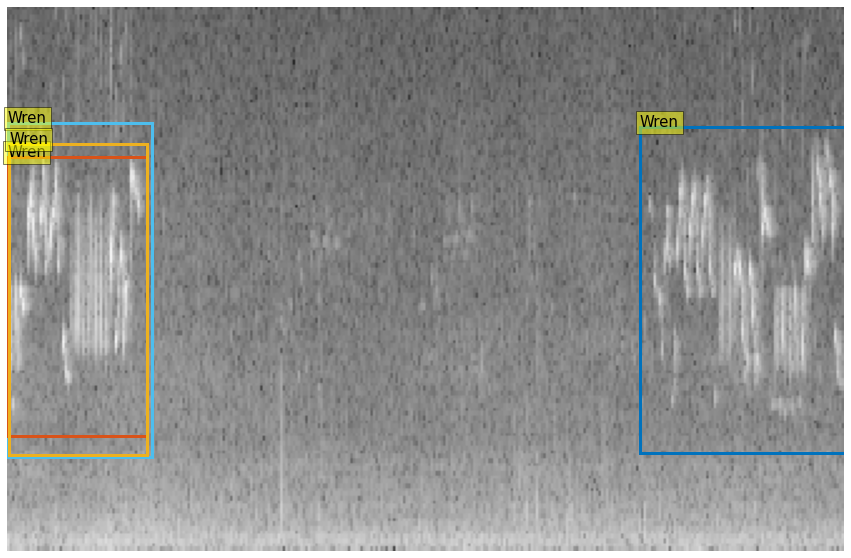

In [49]:
plt.figure(figsize=(16,10))
plt.imshow(img)
ax = plt.gca()
#for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), COLORS * 100):
for a in tmp_annotations:
    xmin, ymin, w, h = a['bbox']
    ax.add_patch(plt.Rectangle((xmin, ymin), w, h,
                               fill=False, color=COLORS[a['id']], linewidth=3))
    cl = a['category_id']
    text = f'{CLASSES[cl]}'#': {p[cl]:0.2f}'
    ax.text(xmin, ymin, text, fontsize=15,
            bbox=dict(facecolor='yellow', alpha=0.5))
plt.axis('off')
plt.show()

In [1]:
def convert_bbox_coco2yolo(img_width, img_height, bbox):
    """
    Convert bounding box from COCO  format to YOLO format

    Parameters
    ----------
    img_width : int
        width of image
    img_height : int
        height of image
    bbox : list[int]
        bounding box annotation in COCO format: 
        [top left x position, top left y position, width, height]

    Returns
    -------
    list[float]
        bounding box annotation in YOLO format: 
        [x_center_rel, y_center_rel, width_rel, height_rel]
    """
    
    # YOLO bounding box format: [x_center, y_center, width, height]
    # (float values relative to width and height of image)
    x_tl, y_tl, w, h = bbox

    dw = 1.0 / img_width
    dh = 1.0 / img_height

    x_center = x_tl + w / 2.0
    y_center = y_tl + h / 2.0

    x = x_center * dw
    y = y_center * dh
    w = w * dw
    h = h * dh

    return [x, y, w, h]

In [2]:
import os
import json
from tqdm import tqdm
import shutil

def make_folders(path="output"):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)
    return path


def convert_coco_json_to_yolo_txt(output_path, json_file):

    path = make_folders(output_path)

    with open(json_file) as f:
        json_data = json.load(f)

    # write _darknet.labels, which holds names of all classes (one class per line)
    label_file = os.path.join(output_path, "_darknet.labels")
    with open(label_file, "w") as f:
        for category in tqdm(json_data["categories"], desc="Categories"):
            category_name = category["name"]
            f.write(f"{category_name}\n")

    for image in tqdm(json_data["images"], desc="Annotation txt for each iamge"):
        img_id = image["id"]
        img_name = image["file_name"]
        img_width = image["width"]
        img_height = image["height"]

        anno_in_image = [anno for anno in json_data["annotations"] if anno["image_id"] == img_id]
        anno_txt = os.path.join(output_path, img_name.split(".")[0] + ".txt")
        with open(anno_txt, "w") as f:
            for anno in anno_in_image:
                category = anno["category_id"]
                bbox_COCO = anno["bbox"]
                x, y, w, h = convert_bbox_coco2yolo(img_width, img_height, bbox_COCO)
                f.write(f"{category} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

    print("Converting COCO Json to YOLO txt finished!")

In [6]:
convert_coco_json_to_yolo_txt("wf_annotations_textfiles", "wf_traincoco.json")

Annotation txt for each iamge: 100%|███████████████████████████████████████████████| 275/275 [00:00<00:00, 2351.88it/s]

Converting COCO Json to YOLO txt finished!


In [3]:
os.listdir()

['.ipynb_checkpoints',
 '.RData',
 '.Rhistory',
 '20220125_162655richfield_shallow_net.h5',
 'accomodation_scraper.ipynb',
 'audio_15sec_split.ipynb',
 'best_leonet_spectrogram_ww_ff.h5',
 'Carnsore_20220519_acoustic_split',
 'Carnsore_20220519_acoustic_split_benchmark',
 'ClooshValley_20220525_acoustic_split',
 'ClooshValley_20220525_acoustic_split_benchmark',
 'data_set_params.py',
 'detr',
 'detr_object_detection.ipynb',
 'detr_transfer_learning.ipynb',
 'djkelly',
 'djkelly.csv',
 'gen_coco_annotations.ipynb',
 'gen_spectrogram_images.ipynb',
 'get_shinyapp_test_samples.ipynb',
 'GitHub',
 'helper_fns.py',
 'hhussey3',
 'hhussey3.csv',
 'irishwildlifesounds',
 'irishwildlifesounds.csv',
 'markshorten',
 'markshorten.csv',
 'markshorten.zip',
 'My Music',
 'My Pictures',
 'My Videos',
 'nialltkeogh',
 'nialltkeogh.csv',
 'nms_slow.py',
 'norfolk_small_cnn.h5',
 'omarcaif',
 'omarcaif.csv',
 'option_screener.ipynb',
 'PPR-ALL.csv',
 'Rahora_20220621_acoustic_split',
 'Rahora_20220621